In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
data = {
    'income':[12,13,14,6,5,4],
    'credit_score':[750,780,800,300,400,460],
    'Status':['YES','YES','YES','NO','NO','NO']
}
df = pd.DataFrame(data)
df

,income,credit_score,Status
0,12,750,YES
1,13,780,YES
2,14,800,YES
3,6,300,NO
4,5,400,NO
5,4,460,NO


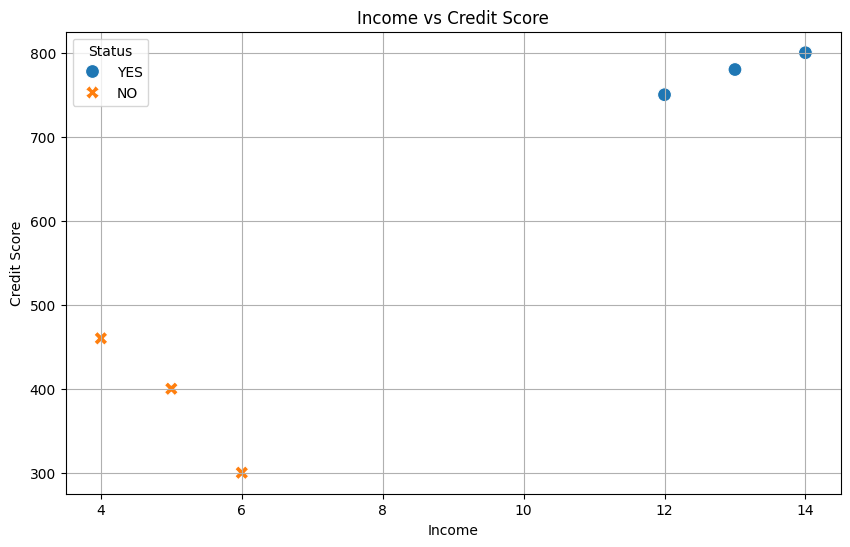

In [3]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', style='Status', s=100)
plt.title('Income vs Credit Score')
plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.grid(True)
plt.show()

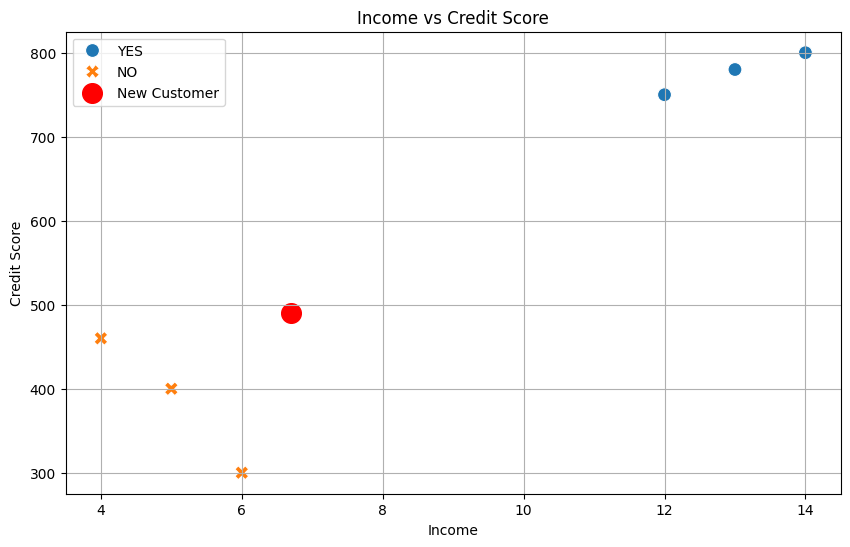

In [6]:
new_customer = [6.7,490]
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='income', y='credit_score', hue='Status', style='Status', s=100)
plt.scatter(new_customer[0], new_customer[1], color='red', s=200, label='New Customer')

plt.title('Income vs Credit Score')
plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.grid(True)
plt.legend()
plt.show()

In [9]:
p1 = [12, 750]
p2 = [21, 900]

distance = np.sqrt((p2[0] - p1[0])**2 + (p2[1] - p1[1])**2)
distance

np.float64(150.26975743641833)

In [19]:
def euclidean_distance(df,points):
    distances = []
    for index, row in df.iterrows():
        dist = np.sqrt((row['income'] - points[0])**2 + (row['credit_score'] - points[1])**2)
        distances.append(dist)
    return distances

# new_customer = np.array([6.7,490])
# df['distance'] = euclidean_distance(df, new_customer)

# df.sort_values('distance')

# # top 3 smallest
# df.nsmallest(3, 'distance')['Status'].value_counts()


def knn_predict(df, new_customer, k=2):
    df['distance'] = euclidean_distance(df, new_customer)
    return df.nsmallest(k, 'distance')['Status'].value_counts().idxmax()

In [20]:
new_customer = np.array([15,750])
knn_predict(df, new_customer, k=3)

'YES'

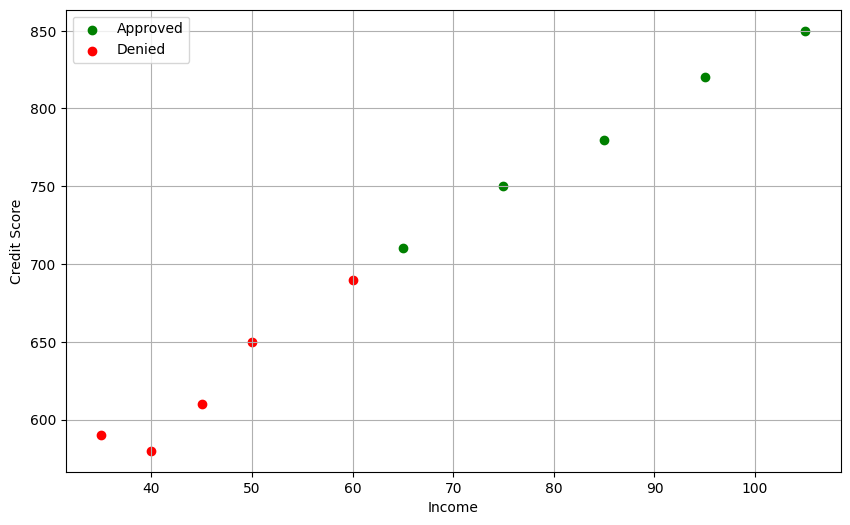

In [23]:
X = np.array([
    [50, 650], [85, 780], [40, 580], [95, 820], [35, 590],
    [65, 710], [75, 750], [45, 610], [105, 850], [60, 690]
])

# 0: Denied, 1: Approved
y = np.array([0, 1, 0, 1, 0, 1, 1, 0, 1, 0])

approved = X[y == 1]
denied = X[y == 0]


plt.figure(figsize=(10, 6))
plt.scatter(approved[:, 0], approved[:, 1], color='green', label='Approved')
plt.scatter(denied[:, 0], denied[:, 1], color='red', label='Denied')
# plt.scatter(new_customer[0], new_customer[1], color='blue', label='New Customer', marker='x', s=200)
plt.xlabel('Income')
plt.ylabel('Credit Score')
plt.legend()
plt.grid()
plt.show()

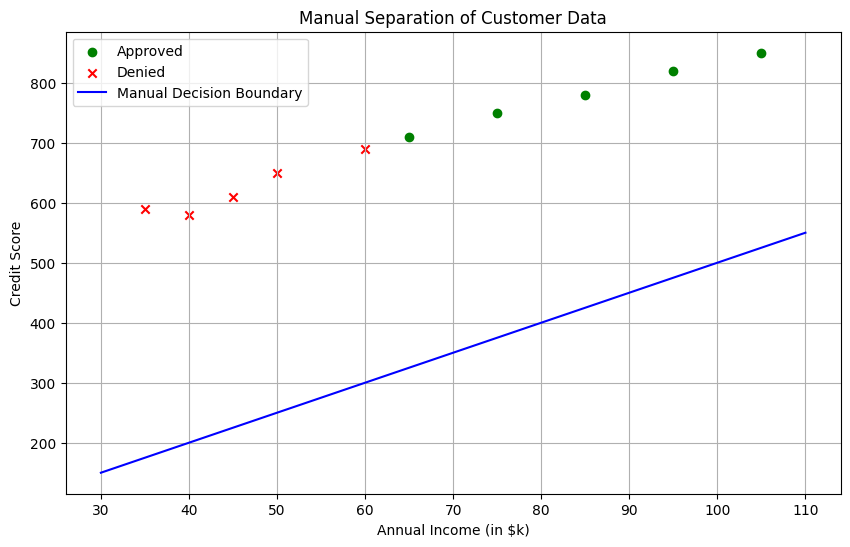

In [29]:
# w1 = -0.45
# w2 = 0.05
# w0 = 5

# try to change different value of weights
w1 = -0.5
w2 = 0.1
w0 = 0

plt.figure(figsize=(10, 6))
plt.scatter(approved[:, 0], approved[:, 1], c='green', marker='o', label='Approved')
plt.scatter(denied[:, 0], denied[:, 1], c='red', marker='x', label='Denied')


income_vals = np.array([X[:, 0].min() - 5, X[:, 0].max() + 5])

score_vals = (-w1 * income_vals - w0) / w2


plt.plot(income_vals, score_vals, 'b-', label='Manual Decision Boundary')
plt.title('Manual Separation of Customer Data')
plt.xlabel('Annual Income (in $k)')
plt.ylabel('Credit Score')
plt.legend()
plt.grid(True)
plt.show()
